In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex06_player_heatmap_after_masking', 'pitch_segmentation_model': 'lightning_logs/version_13/checkpoints/epoch=17-step=288.ckpt', 'pitch_cover_model': 'wandb_logs/ISC-Football/pc7g8srb/checkpoints/epoch=20-step=252.ckpt', 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/j333rvqe/checkpoints/epoch=31-step=896.ckpt', 'unet_with_gaussian_layer': 'wandb_logs/ISC-Football/5yaq0s0v/checkpoints/epoch=31-step=512.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 720, 'height': 405, 'in_channels': 3}, 'spiideo_datamodule': {'batch_size': 16, 'num_workers': 10, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import gc
import cv2
import json
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision.utils import make_grid
import torch.nn.functional as TorchF
import torchvision.transforms.functional as TorchvisionF

import matplotlib.pyplot as plt

from datamodules.spiideo.coco import COCOPredictedAnnotation

from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo.gaussian import Spiideo2DGaussianMaskDataModule, Spiideo2DGaussianMaskDatasetArgs

from models.player_detection.unet_gaussian import UNetHeatmapGaussian
from pipelines.player_detection.location_detector import LocationDetector
from pipelines.player_detection.player_detector import PlayerDetector

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
spiideo_args = SpiideoDatasetArgs(**config['spiideo_dataset'])
spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

ds = spiideo_data_module.dataset('test')
print(f'Dataset with {len(ds)} images.')

id=0 keypoints=array([[3.07416516e+03, 9.89364876e+02, 1.00000000e+00],
       [3.07061060e+03, 1.03780053e+03, 1.00000000e+00]]) keypoints_3d=array([[2.54723261, 3.32357231, 0.89179301, 1.        ],
       [2.54723261, 3.32357231, 0.        , 1.        ]]) position_on_pitch=array([2.54723261, 3.32357231]) bbox=array([3053,  950,   28,   89]) area=952.0 image_id=0 category_id=1
id=0 keypoints=array([[614.83303223, 197.87297516,   1.        ],
       [614.12211914, 207.5601059 ,   1.        ]]) keypoints_3d=array([[2.54723261, 3.32357231, 0.89179301, 1.        ],
       [2.54723261, 3.32357231, 0.        , 1.        ]]) position_on_pitch=array([2.54723261, 3.32357231]) bbox=array([610, 190,   5,  17]) area=952.0 image_id=0 category_id=1
Dataset with 9309 images.


### Inference

In [46]:
IMAGE_IDX = 402
img, coco_img, coco_annot, *_ = ds[IMAGE_IDX]

In [47]:
with open(f'experiments/ex07_inference/results-test/{str(IMAGE_IDX).zfill(6)}.json') as f:
    prediction = json.load(f)
    print(f'{len(prediction)} predictions loaded.')

22 predictions loaded.


In [48]:
world_keypoints = [obj['position_on_pitch'] for obj in prediction if obj['image_id'] == IMAGE_IDX]
world_keypoints = np.array(world_keypoints).T
image_keypoints = coco_img.coordinates_from_world_to_image(world_keypoints[0, :], world_keypoints[1, :])

In [49]:
annot_world_keypoints = np.array([obj.position_on_pitch for obj in coco_annot])[:, :2].T
annot_keypoints = np.array([obj.keypoints[1] for obj in coco_annot])[:, :2].T

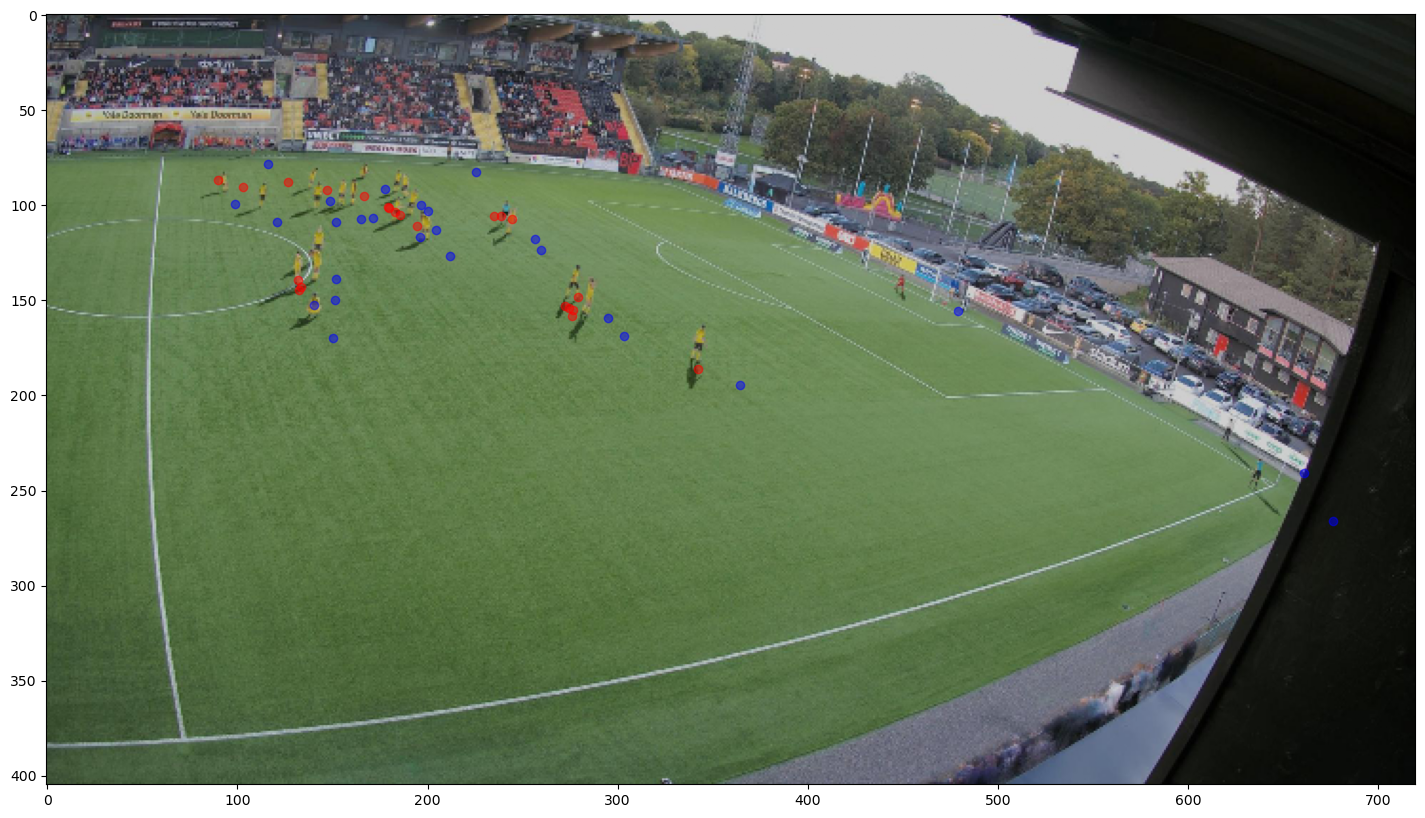

In [50]:
plt.figure(figsize=(20, 10))
plt.imshow(img)
plt.scatter(x=image_keypoints[0, :], y=image_keypoints[1, :], c='red', alpha=0.5)
plt.scatter(x=annot_keypoints[0, :], y=annot_keypoints[1, :], c='blue', alpha=0.5)
plt.show()

In [51]:
world_keypoints.shape
# annot_world_keypoints.shape

(3, 22)

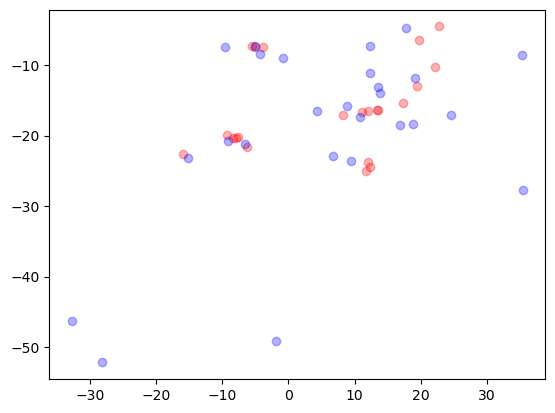

In [52]:
plt.scatter(world_keypoints[0, :], world_keypoints[1, :], c='red', alpha=0.3)
plt.scatter(annot_world_keypoints[0, :], annot_world_keypoints[1, :], c='blue', alpha=0.3)
plt.show()